In [1]:

!pip install transformers accelerate datasets "scikit-learn==1.6.1" pandas nltk --break-system-packages --upgrade -q


import transformers, sys
print("Transformers:", transformers.__version__)
print("Python:", sys.version)


from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incomp

In [ ]:
from google.colab import files
files.upload()

{}

In [2]:
import os
os.listdir()

['.config',
 'True.csv',
 'valid.tsv',
 'train.tsv',
 'drive',
 'Fake.csv',
 'test.tsv',
 'sample_data']

In [3]:

import pandas as pd
import re, nltk, torch
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))



def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9.,!? ]", "", text)
    text = text.lower()
    return " ".join(w for w in text.split() if w not in stop_words)

true_df = pd.read_csv("True.csv", on_bad_lines="skip").head(3500)
fake_df = pd.read_csv("Fake.csv", on_bad_lines="skip").head(3500)

true_df["label"] = 1
fake_df["label"] = 0

df = pd.concat([true_df, fake_df]).sample(frac=1).reset_index(drop=True)


df["text"] = (df["title"].fillna("") + " " + df["text"].fillna("")).apply(clean_text)
df = df.drop_duplicates(subset="text").reset_index(drop=True)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)


train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = val_df["text"].tolist()
val_labels = val_df["label"].tolist()

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

leak = set(train_texts).intersection(set(test_texts))
print("Leakage count:", len(leak))

import random

def augment(text):
    words = text.split()
    if len(words) > 5 and random.random() < 0.3:
        del words[random.randint(0, len(words)-1)]
    return " ".join(words)

train_texts = [augment(t) for t in train_texts]



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Leakage count: 0



=== Logistic Regression ===
Accuracy: 98.57%
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99       350
        True       0.99      0.98      0.99       349

    accuracy                           0.99       699
   macro avg       0.99      0.99      0.99       699
weighted avg       0.99      0.99      0.99       699


=== SVM ===
Accuracy: 99.86%
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00       350
        True       1.00      1.00      1.00       349

    accuracy                           1.00       699
   macro avg       1.00      1.00      1.00       699
weighted avg       1.00      1.00      1.00       699


=== Naive Bayes ===
Accuracy: 96.85%
              precision    recall  f1-score   support

        Fake       0.96      0.97      0.97       350
        True       0.97      0.96      0.97       349

    accuracy                           0.97       699
   macro avg  

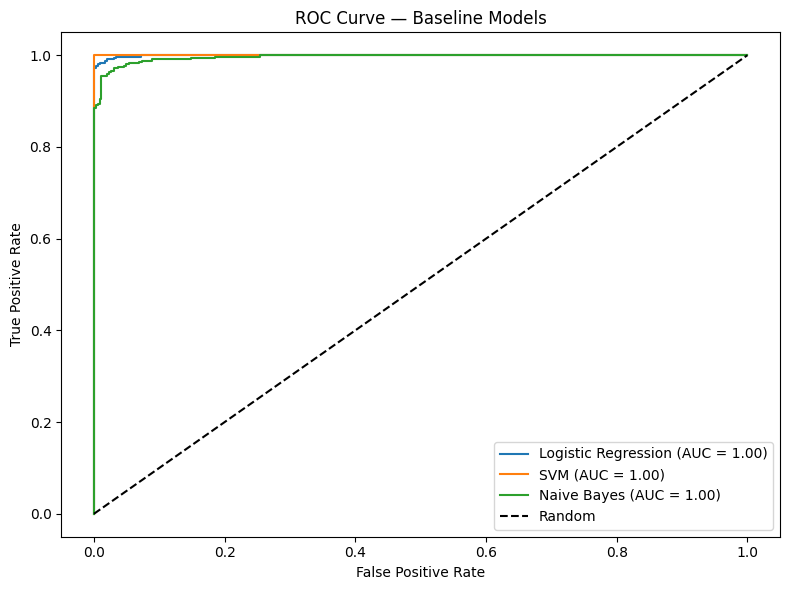

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])
y_train_bl    = train_df["label"].values
y_test_bl     = test_df["label"].values

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM":                 LinearSVC(class_weight="balanced"),
    "Naive Bayes":         ComplementNB(),
}

plt.figure(figsize=(8, 6))

for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train_bl)
    preds = clf.predict(X_test_tfidf)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {round(accuracy_score(y_test_bl, preds)*100, 2)}%")
    print(classification_report(y_test_bl, preds, target_names=["Fake", "True"]))

    if hasattr(clf, "predict_proba"):
        scores = clf.predict_proba(X_test_tfidf)[:, 1]
    else:
        scores = clf.decision_function(X_test_tfidf)

    fpr, tpr, _ = roc_curve(y_test_bl, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Models")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
from transformers import AutoTokenizer, AutoConfig

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_enc = tokenizer(train_texts, truncation=True, padding=True)
val_enc = tokenizer(val_texts, truncation=True, padding=True)
test_enc = tokenizer(test_texts, truncation=True, padding=True)

import datasets

train_dataset = datasets.Dataset.from_dict({**train_enc, "labels": train_labels})
val_dataset = datasets.Dataset.from_dict({**val_enc, "labels": val_labels})
test_dataset = datasets.Dataset.from_dict({**test_enc, "labels": test_labels})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [6]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments

config = AutoConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    dropout=0.2,
    attention_dropout=0.2,
)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config)

data_collator = DataCollatorWithPadding(tokenizer)


use_fp16 = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=use_fp16,
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("CUDA available:", torch.cuda.is_available())

trainer.train()
trainer.save_model("distilbert-fake-news")
tokenizer.save_pretrained("distilbert-fake-news")

CUDA available: True


Epoch,Training Loss,Validation Loss
1,No log,0.010622
2,0.045103,0.011340
3,0.004764,0.007700
4,0.004764,0.000055
5,0.002169,0.003900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert-fake-news/tokenizer_config.json',
 'distilbert-fake-news/tokenizer.json')

In [11]:

from sklearn.metrics import accuracy_score, classification_report

preds = trainer.predict(test_dataset)
pred_labels = preds.predictions.argmax(-1)

print("Accuracy:", accuracy_score(test_labels, pred_labels))
print(classification_report(test_labels, pred_labels))


print("Remaining overlap:", set(train_texts).intersection(set(test_texts)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

sample_raw = "Government confirms climate change is accelerating."

sample = clean_text(sample_raw)

inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    pred = probs.argmax(dim=1).item()
    conf = probs[0][pred].item()

print("Prediction:", "True News" if pred == 1 else "Fake News")
print("Confidence:", conf * 100)

Epoch,Training Loss,Validation Loss


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       350
           1       1.00      1.00      1.00       349

    accuracy                           1.00       699
   macro avg       1.00      1.00      1.00       699
weighted avg       1.00      1.00      1.00       699

Remaining overlap: set()
Prediction: True News
Confidence: 99.70991611480713


In [13]:
from transformers import AutoModelForSequenceClassification
import torch
import datasets
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
liar_model = AutoModelForSequenceClassification.from_pretrained("distilbert-fake-news").to(device)
liar_model.eval()


import pandas as pd


liar_train_df = pd.read_csv("train.tsv", sep="\t", header=None)
liar_val_df   = pd.read_csv("valid.tsv", sep="\t", header=None)
liar_test_df  = pd.read_csv("test.tsv", sep="\t", header=None)

label_map = {
    "true": 1,
    "mostly-true": 1,
    "half-true": 1,
    "barely-true": 0,
    "false": 0,
    "pants-fire": 0,
}

for df_ in [liar_train_df, liar_val_df, liar_test_df]:
    df_["label_bin"] = df_[1].map(label_map)

    df_["text"] = df_[2].apply(clean_text)


liar_texts = liar_test_df["text"].tolist()
liar_labels = liar_test_df["label_bin"].tolist()

liar_enc = tokenizer(liar_texts, truncation=True, padding=True, max_length=256)
liar_dataset = datasets.Dataset.from_dict({**liar_enc, "labels": liar_labels})


liar_trainer = Trainer(
    model=liar_model,
    processing_class=tokenizer,
    data_collator=data_collator,
)


preds = liar_trainer.predict(liar_dataset)
pred_labels = preds.predictions.argmax(-1)


print("LIAR Cross-domain Accuracy:", accuracy_score(liar_labels, pred_labels))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

LIAR Cross-domain Accuracy: 0.5588003157063931


In [14]:
!pip install streamlit transformers torch pyngrok --quiet



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.7 MB/s eta 0:00:00


In [24]:
%%writefile app.py
import re
import streamlit as st
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

st.set_page_config(page_title="Fake News Detection Bot", layout="centered")
st.title("📰 Fake News Detection Chatbot")
st.write("Paste a news article or snippet below and I will predict whether it is fake or real.")

STOP_WORDS = {
    "a", "an", "the", "and", "or", "but", "if", "of", "at", "by", "for",
    "with", "about", "against", "between", "into", "through", "during",
    "before", "after", "above", "below", "to", "from", "up", "down", "in",
    "out", "on", "off", "over", "under", "again", "further", "then", "once",
    "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "this", "that", "these", "those", "it", "its",
}

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9.,!? ]", "", text)
    text = text.lower()
    return " ".join(w for w in text.split() if w not in STOP_WORDS)


@st.cache_resource
def load_model():
    MODEL_REPO = "RayOfLife/FakeBotV2"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)
    model.eval()
    return tokenizer, model


tokenizer, model = load_model()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

user_input = st.text_area("Enter news text:", height=200)

if st.button("Analyze"):
    if user_input.strip() == "":
        st.warning("Please enter some text.")
    else:
        cleaned_input = clean_text(user_input)
        inputs = tokenizer(cleaned_input, return_tensors="pt", truncation=True, padding=True, max_length=256)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)
            pred = probs.argmax(dim=1).item()
            conf = probs[0][pred].item()

        label = "True News" if pred == 1 else "Fake News"
        st.subheader("Result")
        st.write(f"🧠 Prediction: **{label}**")
        st.write(f"📊 Confidence: **{round(conf*100,2)}%**")


!zip -r distilbert-fake-news.zip distilbert-fake-news
from google.colab import files

files.download("app.py")
files.download("distilbert-fake-news.zip")


Overwriting app.py
